In [10]:
# ==========================================================
# PID1 - Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

print("Libraries Loaded Successfully")


Libraries Loaded Successfully


In [11]:
# ==========================================================
# PID2 - Load Dataset
# ==========================================================

df = pd.read_csv(
    "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Outputs/ML_ready_dataset.csv"
)

print(df.shape)

df.head()

(15457, 643)


,SEQN,SDMVPSU,SDMVSTRA,WTINTPRP,WTMECPRP,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,DMDEDUC2,...,URXUHG_WASMISSING,URXUBA_WASMISSING,URXUCD_WASMISSING,URXUCO_WASMISSING,URXUPB_WASMISSING,URXUSB_WASMISSING,URXUTL_WASMISSING,URXUTU_WASMISSING,URXUAS_WASMISSING,Composite_CVD
0,109263,3,156,7891.762435,8951.815567,1,2,5,6,4,...,1,1,1,1,1,1,1,1,1,0
1,109264,1,155,11689.747264,12271.157043,2,13,1,1,4,...,1,1,1,1,1,1,1,1,1,0
2,109265,1,157,16273.825939,16658.764203,1,2,3,3,4,...,1,1,1,1,1,1,1,1,1,0
3,109266,2,168,7825.646112,8154.968193,2,29,5,6,5,...,0,0,0,0,0,0,0,0,0,0
4,109267,1,156,26379.991724,0.000000,2,21,2,2,4,...,1,1,1,1,1,1,1,1,1,0


In [12]:
# ==========================================================
# PID3 - Remove Non-Deployable Variables
# ==========================================================

remove_cols = [
    "SEQN",

    "WTINTPRP",
    "WTMECPRP",

    "WTINT2YR",
    "WTMEC2YR",

    "SDMVPSU",
    "SDMVSTRA"
]

remove_cols = [c for c in remove_cols if c in df.columns]
df.drop(columns=remove_cols, inplace=True)
print(df.shape)

(15457, 638)


In [13]:
# ==========================================================
# PID4 - Prepare Features
# ==========================================================

X = df.drop(columns=["Composite_CVD"])

y = df["Composite_CVD"]

print(X.shape)

print(y.shape)

(15457, 637)
(15457,)


In [14]:
# ==========================================================
# PID5 - Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

print(X_train.shape)

print(X_test.shape)

(12365, 637)
(3092, 637)


In [15]:
# ==========================================================
# PID6 - Train Random Forest
# ==========================================================

rf_model = RandomForestClassifier(

    n_estimators=500,
    max_depth=20,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1

)

rf_model.fit(

    X_train,
    y_train

)

print("Training Completed")

Training Completed


In [16]:
# ==========================================================
# PID7 - Prediction
# ==========================================================

y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:,1]

In [17]:
# ==========================================================
# PID8 - Model Performance
# ==========================================================

results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "MCC"
    ],

    "Score":[

        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred),
        roc_auc_score(y_test,y_prob),
        matthews_corrcoef(y_test,y_pred)

    ]

})

results

,Metric,Score
0,Accuracy,0.898771
1,Precision,0.351351
2,Recall,0.462222
3,F1 Score,0.399232
4,ROC AUC,0.909035
5,MCC,0.348952


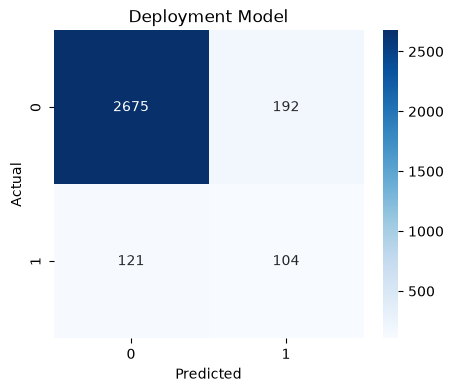

In [18]:
# ==========================================================
# PID9 - Confusion Matrix
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,
    annot=True,
    fmt="d",
    cmap="Blues"

)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Deployment Model")
plt.show()

In [19]:
# ==========================================================
# PID10 - Save Model
# ==========================================================

joblib.dump(

    rf_model,

    "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Models/Random_Forest_Deployment_Model.pkl"

)

print("Deployment Model Saved")

Deployment Model Saved


In [20]:
# ==========================================================
# PID11 - Risk Probability
# ==========================================================

prediction_results = X_test.copy()
prediction_results["Actual"] = y_test.values
prediction_results["Predicted"] = y_pred
prediction_results["Risk_Probability"] = np.round(y_prob * 100, 2)
prediction_results.head()

,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,DMDEDUC2,DMDMARTZ,INDFMPIR,MCQ160A,MCQ160M,MCQ160P,...,URXUCD_WASMISSING,URXUCO_WASMISSING,URXUPB_WASMISSING,URXUSB_WASMISSING,URXUTL_WASMISSING,URXUTU_WASMISSING,URXUAS_WASMISSING,Actual,Predicted,Risk_Probability
7799,1,8,4,4,4,1,0.29,2,2,2,...,1,1,1,1,1,1,1,0,0,0.00
13198,2,7,1,1,4,1,0.04,2,2,2,...,1,1,1,1,1,1,1,0,0,0.00
6382,1,7,3,3,4,1,1.55,2,2,2,...,0,0,0,0,0,0,0,0,0,0.00
14225,1,67,4,4,4,1,3.62,1,2,2,...,0,0,0,0,0,0,0,0,1,65.39
12004,1,9,3,3,4,1,0.81,2,2,2,...,1,1,1,1,1,1,1,0,0,0.00


In [21]:
# ==========================================================
# PID12 - Risk Category
# ==========================================================

def risk_category(prob):

    if prob < 30:
        return "Low"
    elif prob < 70:
        return "Moderate"
    else:
        return "High"

prediction_results["Risk_Category"] = prediction_results[
    "Risk_Probability"
].apply(risk_category)

prediction_results.head()

,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,DMDEDUC2,DMDMARTZ,INDFMPIR,MCQ160A,MCQ160M,MCQ160P,...,URXUCO_WASMISSING,URXUPB_WASMISSING,URXUSB_WASMISSING,URXUTL_WASMISSING,URXUTU_WASMISSING,URXUAS_WASMISSING,Actual,Predicted,Risk_Probability,Risk_Category
7799,1,8,4,4,4,1,0.29,2,2,2,...,1,1,1,1,1,1,0,0,0.00,Low
13198,2,7,1,1,4,1,0.04,2,2,2,...,1,1,1,1,1,1,0,0,0.00,Low
6382,1,7,3,3,4,1,1.55,2,2,2,...,0,0,0,0,0,0,0,0,0.00,Low
14225,1,67,4,4,4,1,3.62,1,2,2,...,0,0,0,0,0,0,0,1,65.39,Moderate
12004,1,9,3,3,4,1,0.81,2,2,2,...,1,1,1,1,1,1,0,0,0.00,Low


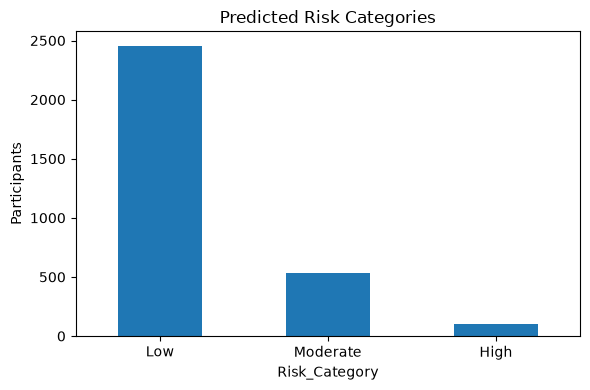

In [22]:
# ==========================================================
# PID13 - Risk Distribution
# ==========================================================

import matplotlib.pyplot as plt

prediction_results["Risk_Category"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Predicted Risk Categories")
plt.ylabel("Participants")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

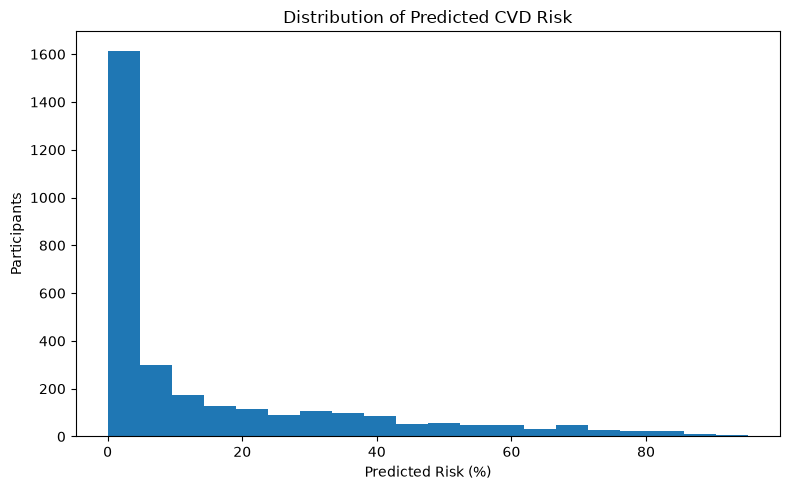

In [23]:
# ==========================================================
# PID14 - Risk Probability Distribution
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(
    prediction_results["Risk_Probability"],
    bins=20
)

plt.xlabel("Predicted Risk (%)")

plt.ylabel("Participants")

plt.title("Distribution of Predicted CVD Risk")

plt.tight_layout()

plt.show()

In [24]:
# ==========================================================
# PID15 - Save Prediction Results
# ==========================================================

prediction_results.to_csv(
"C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Outputs/Deployment_Predictions.csv",
index=False
)
print("Prediction Results Saved Successfully")

Prediction Results Saved Successfully


In [25]:
# ==========================================================
# PID16 - Save Feature Names
# ==========================================================

joblib.dump(
    X.columns.tolist(),
    "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Models/Feature_List.pkl"
)

print("Feature List Saved")

Feature List Saved


In [26]:
# ==========================================================
# PID17 - Feature Importance
# ==========================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)
importance.head(20)

,Feature,Importance
1,RIDAGEYR,0.041095
429,BPQ030_WASMISSING,0.028129
431,BPQ050A_WASMISSING,0.025930
434,BPQ100D_WASMISSING,0.023967
430,BPQ040A_WASMISSING,0.021449
11,BPQ020,0.018970
16,BPQ090D,0.018849
306,URXUCD,0.016995
24,LBXGLU,0.013332
301,LBXMFOS,0.012480


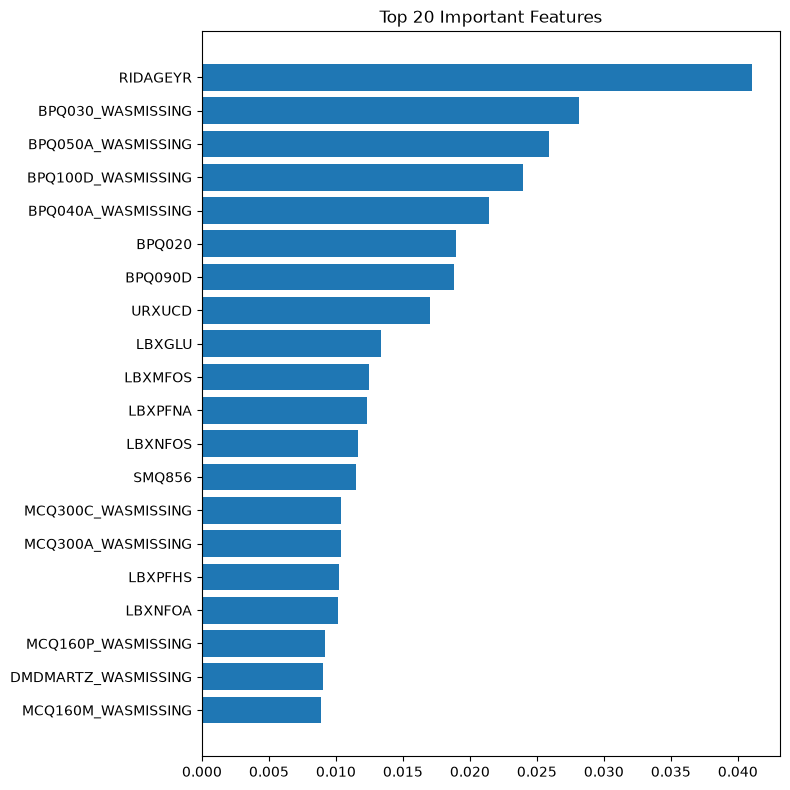

In [27]:
# ==========================================================
# PID18 - Feature Importance Plot
# ==========================================================

top20 = importance.head(20)

plt.figure(figsize=(8,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.tight_layout()
plt.show()

In [28]:
top20 = importance.head(20)

top20

,Feature,Importance
1,RIDAGEYR,0.041095
429,BPQ030_WASMISSING,0.028129
431,BPQ050A_WASMISSING,0.025930
434,BPQ100D_WASMISSING,0.023967
430,BPQ040A_WASMISSING,0.021449
11,BPQ020,0.018970
16,BPQ090D,0.018849
306,URXUCD,0.016995
24,LBXGLU,0.013332
301,LBXMFOS,0.012480


In [29]:
deployment_df = df[
    top20["Feature"].tolist() + ["Composite_CVD"]
]

In [30]:
# ==========================================================
# PID19 - Select Top 20 Features
# ==========================================================

top20 = importance.head(20)

top_features = top20["Feature"].tolist()

print(top_features)

['RIDAGEYR', 'BPQ030_WASMISSING', 'BPQ050A_WASMISSING', 'BPQ100D_WASMISSING', 'BPQ040A_WASMISSING', 'BPQ020', 'BPQ090D', 'URXUCD', 'LBXGLU', 'LBXMFOS', 'LBXPFNA', 'LBXNFOS', 'SMQ856', 'MCQ300C_WASMISSING', 'MCQ300A_WASMISSING', 'LBXPFHS', 'LBXNFOA', 'MCQ160P_WASMISSING', 'DMDMARTZ_WASMISSING', 'MCQ160M_WASMISSING']


In [31]:
# ==========================================================
# PID20 - Deployment Dataset
# ==========================================================

deployment_df = df[top_features + ["Composite_CVD"]]

print(deployment_df.shape)

deployment_df.head()

(15457, 21)


,RIDAGEYR,BPQ030_WASMISSING,BPQ050A_WASMISSING,BPQ100D_WASMISSING,BPQ040A_WASMISSING,BPQ020,BPQ090D,URXUCD,LBXGLU,LBXMFOS,...,LBXNFOS,SMQ856,MCQ300C_WASMISSING,MCQ300A_WASMISSING,LBXPFHS,LBXNFOA,MCQ160P_WASMISSING,DMDMARTZ_WASMISSING,MCQ160M_WASMISSING,Composite_CVD
0,2,1,1,1,1,2,2,0.0390,102.0,1.1,...,2.7,0,1,1,1.0,1.3,1,1,1,0
1,13,1,1,1,1,2,2,0.0695,97.0,0.5,...,1.4,0,1,1,0.5,0.8,1,1,1,0
2,2,1,1,1,1,2,2,0.0390,102.0,1.1,...,2.7,0,1,1,1.0,1.3,1,1,1,0
3,29,1,1,1,1,2,2,0.0390,94.0,0.5,...,1.1,1,0,0,0.7,0.9,0,0,0,0
4,21,1,1,1,1,2,2,0.1270,94.0,0.5,...,1.5,1,0,0,0.5,0.8,0,0,0,0


In [32]:
# ==========================================================
# PID21 - Train Test Split
# ==========================================================

X = deployment_df.drop(columns=["Composite_CVD"])

y = deployment_df["Composite_CVD"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)

(12365, 20)


In [33]:
# ==========================================================
# PID22 - Train Deployment Model
# ==========================================================

deployment_model = RandomForestClassifier(

    n_estimators=500,

    max_depth=20,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)

deployment_model.fit(X_train, y_train)

print("Deployment Model Trained")

Deployment Model Trained


In [34]:
# ==========================================================
# PID23 - Evaluate Deployment Model
# ==========================================================

y_pred = deployment_model.predict(X_test)

y_prob = deployment_model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("ROC AUC  :", roc_auc_score(y_test,y_prob))
print("MCC      :", matthews_corrcoef(y_test,y_pred))

Accuracy : 0.8619016817593791
Precision: 0.2823275862068966
Recall   : 0.5822222222222222
F1 Score : 0.3802612481857765
ROC AUC  : 0.8888873386815487
MCC      : 0.3389903387534244


In [35]:
# ==========================================================
# PID24 - Save Deployment Model
# ==========================================================

joblib.dump(

    deployment_model,

    "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Models/CardioAI_Model.pkl"

)

joblib.dump(

    top_features,

    "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Models/CardioAI_Features.pkl"

)

print("Deployment Model Saved")

Deployment Model Saved
